In [1]:
# To Supress Unnecessary Warnings
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Data Processing
import numpy as np
import pandas as pd

# Utilities
from sklearn.preprocessing import StandardScaler
import joblib

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [2]:
DATA_PATH = "../Data/OfflineTrainingData.csv"

OUTLIER_COLUMNS = ['AQI', 'Temp', 'Hum']

INPUT_FEATURES = ['AQI', 'Temp', 'Hum', 'Pres', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'is_weekend']
TARGET_FEATURES = ['AQI', 'Temp', 'Hum']

SEQ_LEN = 120
HORIZON_ORDER = ['1min', '5min', '15min']
HORIZONS = {
    '1min': 12,
    '5min': 60,
    '15min': 180
}
TRAINING_DATA_PERCENTAGE = 0.8

SCALED_INPUT_FEATURES = ['AQI', 'Temp', 'Hum']
UNSCALED_INPUT_FEATURES = ['Pres', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'is_weekend']

OFFLINE_LEARNING_RATE = 0.001

In [3]:
def cap_outliers_iqr(df, columns):
    bounds = {}
    df = df.copy()

    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[col] = df[col].clip(lower=lower, upper=upper)

        bounds[col] = {
            "lower": lower,
            "upper": upper
        }
    return df, bounds

In [4]:
def process_raw_sensor_data(df):
    # Capping Outlier Columns
    df, bounds = cap_outliers_iqr(df, OUTLIER_COLUMNS)

    # Add Hourly Features
    df['hour_sin'] = np.sin(2 * np.pi * df['Timestamp'].dt.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['Timestamp'].dt.hour / 24)

    # Add Daily Features
    df['day_sin'] = np.sin(2 * np.pi * df['Timestamp'].dt.dayofweek / 7)
    df['day_cos'] = np.cos(2 * np.pi * df['Timestamp'].dt.dayofweek / 7)

    df['is_weekend'] = df['Timestamp'].dt.dayofweek >= 5
    df['is_weekend'] = df['is_weekend'].astype(int)

    return df, bounds

In [5]:
def build_lstm_sequences(df):
    X, y = [], []

    x_data = df[INPUT_FEATURES].values
    y_data = df[TARGET_FEATURES].values

    max_horizon = max(HORIZONS.values())

    for i in range(SEQ_LEN, len(df) - max_horizon):
        # ---- Input sequence ----
        X.append(x_data[i - SEQ_LEN:i])

        # ---- Target vector ----
        target = []
        for col_idx in range(len(TARGET_FEATURES)):
            for h in HORIZON_ORDER:
                target.append(y_data[i + HORIZONS[h], col_idx])

        y.append(target)

    return np.array(X), np.array(y)

In [6]:
def split_train_val_data(X, y):
    # Split data into train and test sets
    split_idx = int(len(X) * TRAINING_DATA_PERCENTAGE)

    X_train, X_val = X[:split_idx], X[split_idx:]
    y_train, y_val = y[:split_idx], y[split_idx:]
    return X_train, X_val, y_train, y_val

In [7]:
def scale_inputs(X_train, X_val):
    scaled_feature_indices = [INPUT_FEATURES.index(f) for f in SCALED_INPUT_FEATURES]

    input_scalers = []
    X_train_scaled = X_train.copy()
    X_val_scaled = X_val.copy()

    for idx in scaled_feature_indices:
        scaler = StandardScaler()

        # Fit on training input feature idx (across all timesteps)
        X_train_scaled[:, :, idx] = scaler.fit_transform(
            X_train[:, :, idx].reshape(-1, 1)
        ).reshape(X_train.shape[0], X_train.shape[1])

        # Transform validation input feature idx
        X_val_scaled[:, :, idx] = scaler.transform(
            X_val[:, :, idx].reshape(-1, 1)
        ).reshape(X_val.shape[0], X_val.shape[1])

        input_scalers.append(scaler)
    return X_train_scaled, X_val_scaled, input_scalers

In [8]:
def scale_targets(y_train, y_val):
    target_scalers = []
    y_train_scaled = y_train.copy()
    y_val_scaled = y_val.copy()

    num_targets = y_train.shape[1]

    for i in range(num_targets):
        scaler = StandardScaler()

        # Fit on training target i
        y_train_scaled[:, i] = scaler.fit_transform(
            y_train[:, i].reshape(-1, 1)
        ).flatten()

        # Transform validation target i
        y_val_scaled[:, i] = scaler.transform(
            y_val[:, i].reshape(-1, 1)
        ).flatten()

        target_scalers.append(scaler)

    return y_train_scaled, y_val_scaled, target_scalers

In [9]:
# Load dataset
data = pd.read_csv(DATA_PATH, parse_dates=["Timestamp"])

# Process raw sensor data
data, cap_iqr_bounds = process_raw_sensor_data(data)

# Build LSTM sequences
X, y = build_lstm_sequences(data)

# Split data into train and validation sets
X_train, X_val, y_train, y_val = split_train_val_data(X, y)

# Scale Inputs
X_train_scaled, X_val_scaled, input_scalers = scale_inputs(X_train, X_val)
# Scale Targets
y_train_scaled, y_val_scaled, target_scalers = scale_targets(y_train, y_val)

In [10]:
# Correctness of Data Dimensions before Training
print(X.shape)  # X shape: (samples, 120, 3)
print(y.shape)  # y shape: (samples, 9)

(120607, 120, 9)
(120607, 9)


In [11]:
model = Sequential([
    Input(shape=(120, len(INPUT_FEATURES))),

    LSTM(64, return_sequences=True, recurrent_dropout=0.1),
    Dropout(0.2),

    LSTM(32, return_sequences=False, recurrent_dropout=0.1),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dense(9)
])


In [12]:
model.compile(
    optimizer=Adam(learning_rate=OFFLINE_LEARNING_RATE),
    loss='mse',
    metrics=['mae']
)

In [13]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=13,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,  # LR is reduced by this factor
    patience=5,  # wait 5 epochs without improvement
    min_lr=1e-6,  # don't go below this LR
    verbose=1
)

history = model.fit(
    X_train_scaled,
    y_train_scaled,
    validation_data=(X_val_scaled, y_val_scaled),
    epochs=30,
    batch_size=32,
    shuffle=False,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/30
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 260s 84ms/step - loss: 0.1493 - mae: 0.2392 - val_loss: 1.6777 - val_mae: 1.0136 - learning_rate: 0.0010
Epoch 2/30
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 247s 82ms/step - loss: 0.1457 - mae: 0.2311 - val_loss: 1.9857 - val_mae: 1.1465 - learning_rate: 0.0010
Epoch 3/30
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 471s 156ms/step - loss: 0.1431 - mae: 0.2382 - val_loss: 1.8980 - val_mae: 1.1231 - learning_rate: 0.0010
Epoch 4/30
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 241s 80ms/step - loss: 0.1451 - mae: 0.2397 - val_loss: 1.5754 - val_mae: 0.9945 - learning_rate: 0.0010
Epoch 5/30
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 239s 79ms/step - loss: 0.1481 - mae: 0.2402 - val_loss: 1.4647 - val_mae: 0.9878 - learning_rate: 0.0010
Epoch 6/30
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 246s 81ms/step - loss: 0.1487 - mae: 0.2374 - val_loss: 1.3027 - val_mae: 0.9087 - learning_rate: 0.0010
Epoch 7/30
3016/3016 ━━━━━━━━━━━━━━━━━━━━ 211s 70ms/step - loss: 0.1392 - mae: 0.2326 - val_loss: 1.3196 - val_mae: 0

In [15]:
# Save the trained model
model.save("../Models&Scalers/LSTM/model.keras")

# ---- Target scaler metadata ----
target_meta = {
    "target_features": TARGET_FEATURES,
    "horizons": list(HORIZONS.keys()),
    "order": "feature_major"
}

# ---- Input scaler metadata ----
input_meta = {
    "input_features": INPUT_FEATURES,
    "scaled_features": SCALED_INPUT_FEATURES,
    "unscaled_features": UNSCALED_INPUT_FEATURES
}

# ---- Outlier handling metadata ----
outlier_meta = {
    "method": "iqr_capping",
    "columns": OUTLIER_COLUMNS,
    "bounds": cap_iqr_bounds
}

# ---- Save everything together ----
joblib.dump(
    {
        "target_scalers": target_scalers,
        "target_meta": target_meta,
        "input_scalers": input_scalers,
        "input_meta": input_meta,
        "outlier_meta": outlier_meta
    },
    "../Models&Scalers/LSTM/scaler_bundle.pkl"
)


['../Models&Scalers/LSTM/scaler_bundle.pkl']

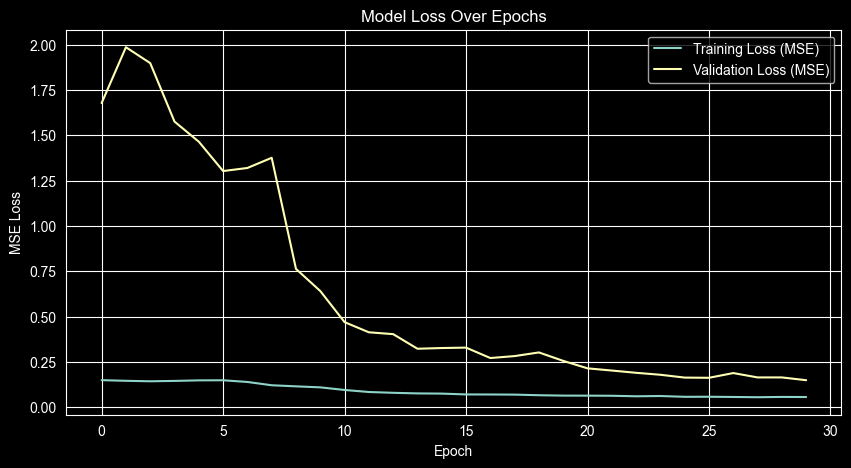

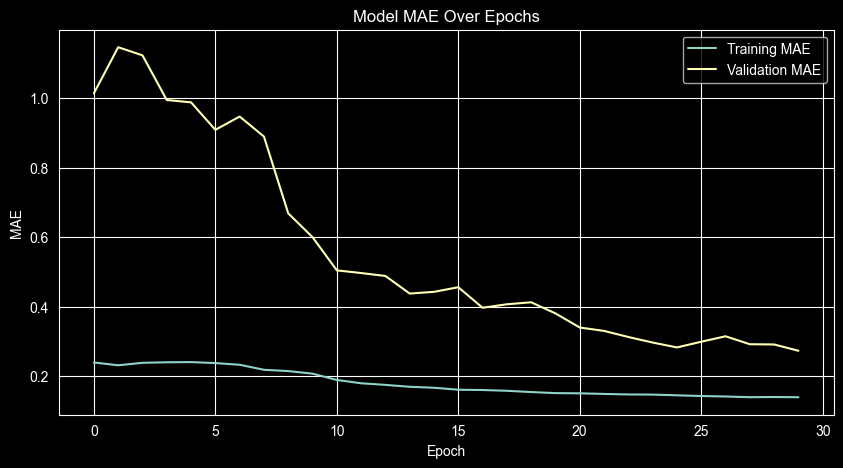

In [19]:
# Plot Loss
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Training Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Model Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot MAE
plt.figure(figsize=(10,5))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model MAE Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
y_pred_scaled = model.predict(X_val_scaled)

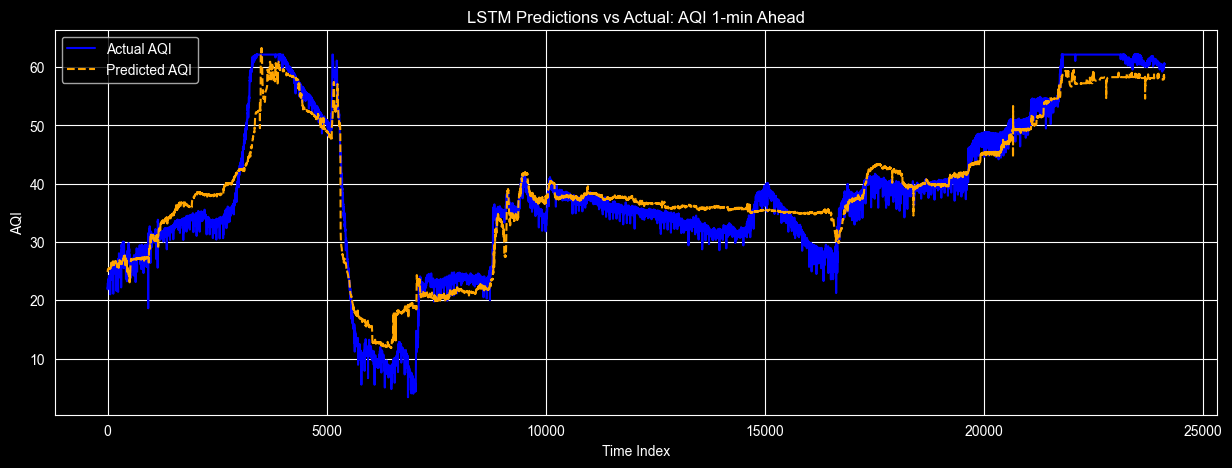

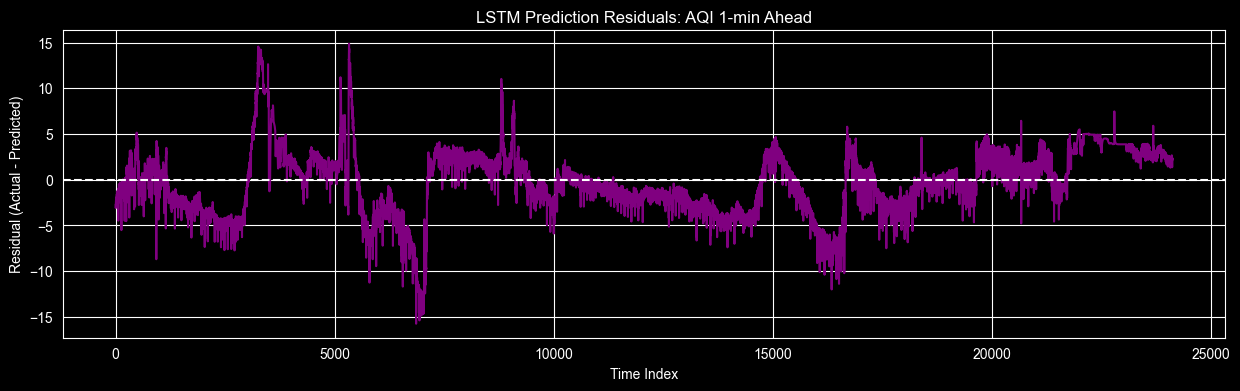

In [20]:
# Inverse scale column by column
y_pred = np.zeros_like(y_pred_scaled)
y_test_actual = np.zeros_like(y_val_scaled)

for i, scaler in enumerate(target_scalers):
    y_pred[:, i] = scaler.inverse_transform(y_pred_scaled[:, i].reshape(-1, 1)).flatten()
    y_test_actual[:, i] = scaler.inverse_transform(y_val_scaled[:, i].reshape(-1, 1)).flatten()

# Focus on AQI 1-min (first column)
aqi_actual = y_test_actual[:, 0]
aqi_pred = y_pred[:, 0]

plt.figure(figsize=(15, 5))
plt.plot(aqi_actual, label='Actual AQI', color='blue')
plt.plot(aqi_pred, label='Predicted AQI', color='orange', linestyle='--')
plt.title('LSTM Predictions vs Actual: AQI 1-min Ahead')
plt.xlabel('Time Index')
plt.ylabel('AQI')
plt.legend()
plt.grid(True)
plt.show()

residuals = aqi_actual - aqi_pred
plt.figure(figsize=(15, 4))
plt.plot(residuals, color='purple')
plt.axhline(0,  linestyle='--')
plt.title('LSTM Prediction Residuals: AQI 1-min Ahead')
plt.xlabel('Time Index')
plt.ylabel('Residual (Actual - Predicted)')
plt.grid(True)
plt.show()
